## Turbine Fault IIoT Data
📄 Dataset Description

This dataset represents Industrial IoT (IIoT) sensor logs collected from a turbine system.
Each record in the dataset corresponds to a fault detection event recorded by the monitoring system at a specific timestamp.
It helps engineers and analysts study fault patterns, timing, and recurrence to improve maintenance scheduling, fault prediction, and system reliability.

## 🧩 Dataset Structure

| Column Name  | Data Type            | Description                                                                                         |
| ------------ | -------------------- | --------------------------------------------------------------------------------------------------- |
| **DateTime** | `datetime`           | The exact date and time when the fault occurred. Used for trend and time-series analysis.           |
| **Time**     | `float` (epoch time) | UNIX timestamp (seconds since 1970). Useful for computing time intervals programmatically.          |
| **Fault**    | `string`             | The type of fault detected (e.g., `GF`, `AF`, `TF`, etc.). Represents categories of turbine faults. |


## 🧠 Possible Fault Types
| Fault Code | Meaning (Example) | Description                                          |
| ---------- | ----------------- | ---------------------------------------------------- |
| **GF**     | Generator Fault   | Issues in generator components like stator or rotor. |
| **AF**     | Air Flow Fault    | Abnormal air intake or exhaust pressure.             |
| **TF**     | Temperature Fault | Overheating or temperature sensor anomalies.         |
| **VF**     | Vibration Fault   | Excessive turbine vibration.                         |
| **LF**     | Lubrication Fault | Lubrication oil level or pressure issue.             |


In [1]:
import pandas as pd

In [39]:
df = pd.read_csv("fault_data.csv")
df.head()

,DateTime,Time,Fault
0,2014-05-14 14:39:44,1.400096e+09,GF
1,2014-05-14 14:50:24,1.400097e+09,GF
2,2014-05-14 14:58:56,1.400098e+09,GF
3,2014-05-14 15:09:36,1.400098e+09,GF
4,2014-05-14 15:20:16,1.400099e+09,GF


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DateTime  553 non-null    object 
 1   Time      553 non-null    float64
 2   Fault     553 non-null    object 
dtypes: float64(1), object(2)
memory usage: 13.1+ KB


In [17]:
df.describe()

,Time
count,5.530000e+02
mean,1.414452e+09
std,5.194956e+06
min,1.400096e+09
25%,1.412770e+09
50%,1.414496e+09
75%,1.418045e+09
max,1.421385e+09


In [18]:
df['Fault'].value_counts()

Fault
FF    254
EF    174
AF     62
GF     43
MF     20
Name: count, dtype: int64

## Data Cleaning

Check for missing values, duplicates, and ensure DateTime is in datetime format.

In [19]:
df.isnull().sum()

DateTime    0
Time        0
Fault       0
dtype: int64

In [20]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
548    False
549    False
550    False
551    False
552    False
Length: 553, dtype: bool

In [23]:
# Convert to datetime
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [24]:
df.head()

,DateTime,Time,Fault
0,2014-05-14 14:39:44,1.400096e+09,GF
1,2014-05-14 14:50:24,1.400097e+09,GF
2,2014-05-14 14:58:56,1.400098e+09,GF
3,2014-05-14 15:09:36,1.400098e+09,GF
4,2014-05-14 15:20:16,1.400099e+09,GF


## Add Time-Based Features

You can extract time-based attributes for trend analysis.

In [25]:
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['Weekday'] = df['DateTime'].dt.day_name()

In [26]:
df.head()

,DateTime,Time,Fault,Year,Month,Day,Hour,Weekday
0,2014-05-14 14:39:44,1.400096e+09,GF,2014,5,14,14,Wednesday
1,2014-05-14 14:50:24,1.400097e+09,GF,2014,5,14,14,Wednesday
2,2014-05-14 14:58:56,1.400098e+09,GF,2014,5,14,14,Wednesday
3,2014-05-14 15:09:36,1.400098e+09,GF,2014,5,14,15,Wednesday
4,2014-05-14 15:20:16,1.400099e+09,GF,2014,5,14,15,Wednesday


## Fault Frequency Analysis

See which faults occur most often.

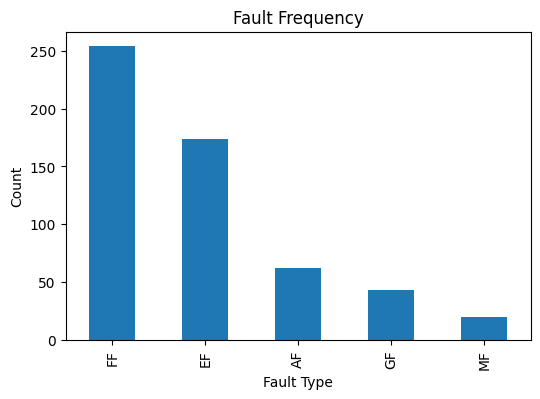

In [27]:
import matplotlib.pyplot as plt

fault_counts = df['Fault'].value_counts()
fault_counts.plot(kind='bar', figsize=(6,4))
plt.title('Fault Frequency')
plt.xlabel('Fault Type')
plt.ylabel('Count')
plt.show()

## Trend Over Time

Analyze fault trends over days or months.

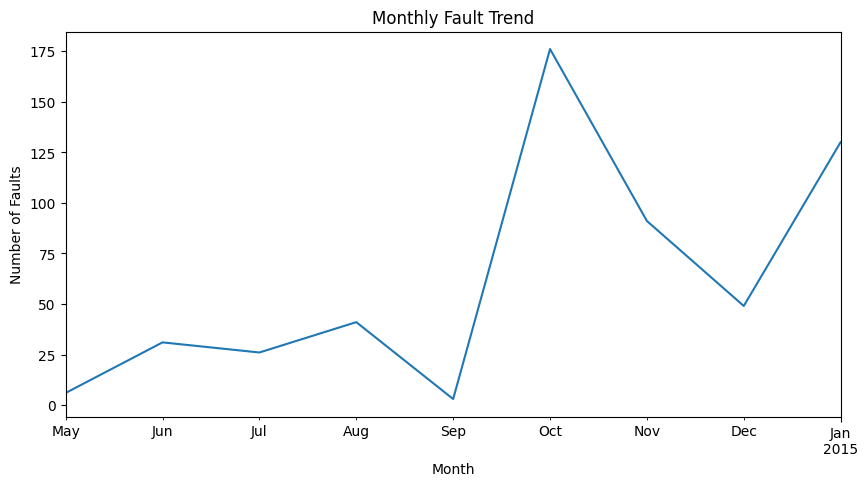

In [28]:
df.set_index('DateTime', inplace=True)
monthly_faults = df.resample('M').size()

monthly_faults.plot(figsize=(10,5))
plt.title('Monthly Fault Trend')
plt.xlabel('Month')
plt.ylabel('Number of Faults')
plt.show()

## Fault Distribution by Hour/Weekday

Check if faults happen more during specific times.

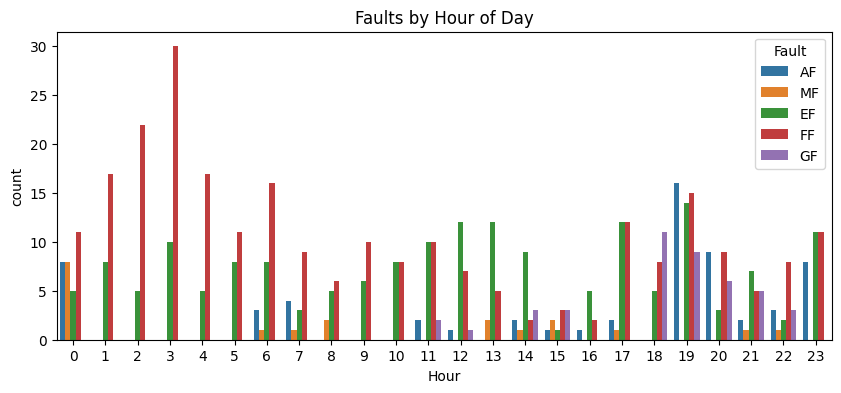

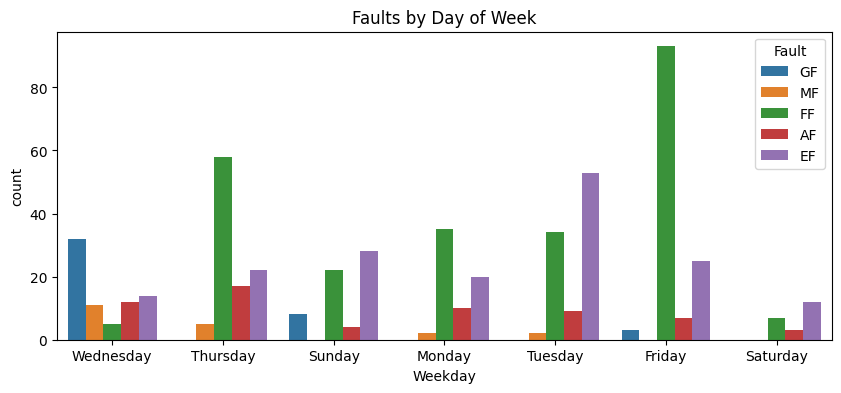

In [29]:
import seaborn as sns

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Hour', hue='Fault')
plt.title('Faults by Hour of Day')
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Weekday', hue='Fault')
plt.title('Faults by Day of Week')
plt.show()

## Fault Correlation or Transition

If you have multiple fault types (GF, AF, TF, etc.), check transitions between them.

In [35]:
df['NextFault'] = df['Fault'].shift(-1)
transition = pd.crosstab(df['Fault'], df['NextFault'])

In [36]:
transition

NextFault,AF,EF,FF,GF,MF
Fault,,,,,
AF,45,3,1,0,12
EF,4,82,86,1,1
FF,2,85,165,2,0
GF,1,2,0,39,1
MF,10,2,2,0,6
